defaultdict(<class 'int'>, {2401: 34, 2400: 107, 2399: 39, 0: 4, 2395: 2, 2406: 3, 2402: 3, 2398: 2, 2396: 2, 2405: 2, 2394: 1})


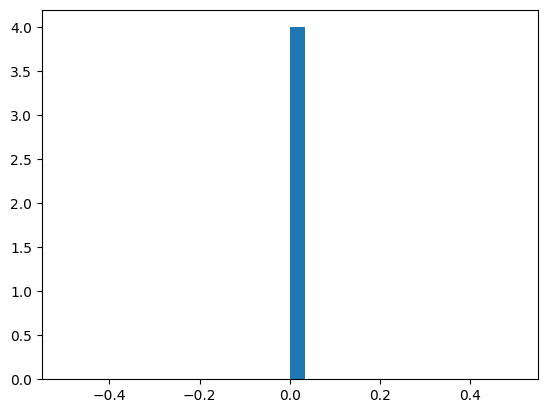

In [47]:


from pprint import pprint
from collections import defaultdict

import matplotlib.pyplot as plt


def find_matching(lines, reg):
    indices = []

    for i, l in enumerate(lines):
        if l.find(reg) != -1:
            indices.append(i)

    return indices


def parse_labels(sub_id):
    lines = open(f"../labels/raw/labels_{sub_id}.csv").readlines()

    start_run_ids = find_matching(lines, "Debut_run")
    end_run_ids = find_matching(lines, "Fin_run")

    run_lines_list = [lines[start:end] for start, end in zip(start_run_ids, end_run_ids)]


    trigger_lines = [line for line in run_lines_list[0] if line.find("trigger") > 0]
    times = [int(line.split(',')[3].split("trigger ")[-1]) for line in trigger_lines]

    bucket = defaultdict(int)
    vals = []

    for t0, t1 in zip(times[:-1], times[1:]):
        bucket[t1 - t0] += 1

        if abs((t1 - t0) - 2400) > 10:
            vals.append(t1 - t0)

        if t1 - t0 < 0:
            print(t1, t0)

    inv = {}
    for k, v in bucket.items():
        inv[v] = k

    print(bucket)
    plt.hist(vals, bins=30)
    # plt.scatter(bucket.keys(), bucket.values())

parse_labels(5)

In [54]:
a = "900 3500 4400 6100 3600 3600 5400 2700 4900 4300 4800 4200 3300 4800 5200 3100 5500 3900 4400 4700 4000 3400 5100 4900 3600 4200 4000 5100 4800 2800 5400 3400 4400 4500 4200 3500 5100 3500 4700 5400 4500 4500 3200 4200 4700 4200 4500 3900 3700 4600 5200 3100 5800 3400 4800 3800 4200 3900 4400 5100 4400 3000 5700 4600 4000 4100 4700 4100 4000 4300 4700 2800 5900 3200 5400 4000 3400 3900 6000 4100 4300 3100 5000 4800 4100 3300 5100 3300 4900 3800 5200 4400 4500 3800 5100 4000 4300 3100 5300 3000"

a = [int(v) / 1000 for v in a.split(" ")]

import numpy as np

np.cumsum(a, axis=0)



array([  0.9,   4.4,   8.8,  14.9,  18.5,  22.1,  27.5,  30.2,  35.1,
        39.4,  44.2,  48.4,  51.7,  56.5,  61.7,  64.8,  70.3,  74.2,
        78.6,  83.3,  87.3,  90.7,  95.8, 100.7, 104.3, 108.5, 112.5,
       117.6, 122.4, 125.2, 130.6, 134. , 138.4, 142.9, 147.1, 150.6,
       155.7, 159.2, 163.9, 169.3, 173.8, 178.3, 181.5, 185.7, 190.4,
       194.6, 199.1, 203. , 206.7, 211.3, 216.5, 219.6, 225.4, 228.8,
       233.6, 237.4, 241.6, 245.5, 249.9, 255. , 259.4, 262.4, 268.1,
       272.7, 276.7, 280.8, 285.5, 289.6, 293.6, 297.9, 302.6, 305.4,
       311.3, 314.5, 319.9, 323.9, 327.3, 331.2, 337.2, 341.3, 345.6,
       348.7, 353.7, 358.5, 362.6, 365.9, 371. , 374.3, 379.2, 383. ,
       388.2, 392.6, 397.1, 400.9, 406. , 410. , 414.3, 417.4, 422.7,
       425.7])

In [65]:
b = """{'nostim.bmp';...
 'Morphs_IRM\MORPH_95_PERCENT_FAMILIARITY\morph_95_3.bmp';...
 'Morphs_IRM\MORPH_45_PERCENT_FAMILIARITY\morph_45_6.bmp';...
 'Morphs_IRM\MORPH_5_PERCENT_FAMILIARITY\morph_5_6.bmp';...
 'Morphs_IRM\MORPH_15_PERCENT_FAMILIARITY\morph_15_1.bmp';...
 'Morphs_IRM\MORPH_75_PERCENT_FAMILIARITY\morph_75_6.bmp';...
 'Morphs_IRM\MORPH_85_PERCENT_FAMILIARITY\morph_85_2.bmp';...
 'Morphs_IRM\MORPH_45_PERCENT_FAMILIARITY\morph_45_3.bmp';...
 'Morphs_IRM\MORPH_35_PERCENT_FAMILIARITY\morph_35_4.bmp';...
 'nostim.bmp';...
 'Morphs_IRM\MORPH_55_PERCENT_FAMILIARITY\morph_55_4.bmp';...
 'Morphs_IRM\MORPH_85_PERCENT_FAMILIARITY\morph_85_8.bmp';...
 'Morphs_IRM\MORPH_55_PERCENT_FAMILIARITY\morph_55_6.bmp';...
 'nostim.bmp';...
 'Morphs_IRM\MORPH_5_PERCENT_FAMILIARITY\morph_5_4.bmp';...
 'Morphs_IRM\MORPH_5_PERCENT_FAMILIARITY\morph_5_2.bmp';...
 'Morphs_IRM\MORPH_95_PERCENT_FAMILIARITY\morph_95_4.bmp';...
 'Morphs_IRM\MORPH_35_PERCENT_FAMILIARITY\morph_35_8.bmp';...
 'nostim.bmp';...
 'Morphs_IRM\MORPH_25_PERCENT_FAMILIARITY\morph_25_7.bmp';...
 'Morphs_IRM\MORPH_45_PERCENT_FAMILIARITY\morph_45_7.bmp';...
 'Morphs_IRM\MORPH_75_PERCENT_FAMILIARITY\morph_75_9.bmp';...
 'Morphs_IRM\MORPH_45_PERCENT_FAMILIARITY\morph_45_4.bmp';...
 'nostim.bmp';...
 'Morphs_IRM\MORPH_55_PERCENT_FAMILIARITY\morph_55_1.bmp';...
 'Morphs_IRM\MORPH_35_PERCENT_FAMILIARITY\morph_35_2.bmp';...
 'Morphs_IRM\MORPH_15_PERCENT_FAMILIARITY\morph_15_9.bmp';...
 'Morphs_IRM\MORPH_35_PERCENT_FAMILIARITY\morph_35_7.bmp';...
 'Morphs_IRM\MORPH_55_PERCENT_FAMILIARITY\morph_55_2.bmp';...
 'Morphs_IRM\MORPH_55_PERCENT_FAMILIARITY\morph_55_9.bmp';...
 'Morphs_IRM\MORPH_35_PERCENT_FAMILIARITY\morph_35_6.bmp';...
 'Morphs_IRM\MORPH_95_PERCENT_FAMILIARITY\morph_95_6.bmp';...
 'Morphs_IRM\MORPH_25_PERCENT_FAMILIARITY\morph_25_5.bmp';...
 'nostim.bmp';...
 'Morphs_IRM\MORPH_95_PERCENT_FAMILIARITY\morph_95_7.bmp';...
 'Morphs_IRM\MORPH_95_PERCENT_FAMILIARITY\morph_95_1.bmp';...
 'Morphs_IRM\MORPH_15_PERCENT_FAMILIARITY\morph_15_5.bmp';...
 'Morphs_IRM\MORPH_25_PERCENT_FAMILIARITY\morph_25_8.bmp';...
 'Morphs_IRM\MORPH_45_PERCENT_FAMILIARITY\morph_45_1.bmp';...
 'Morphs_IRM\MORPH_65_PERCENT_FAMILIARITY\morph_65_1.bmp';...
 'Morphs_IRM\MORPH_35_PERCENT_FAMILIARITY\morph_35_1.bmp';...
 'Morphs_IRM\MORPH_5_PERCENT_FAMILIARITY\morph_5_5.bmp';...
 'Morphs_IRM\MORPH_5_PERCENT_FAMILIARITY\morph_5_1.bmp';...
 'Morphs_IRM\MORPH_25_PERCENT_FAMILIARITY\morph_25_1.bmp';...
 'Morphs_IRM\MORPH_65_PERCENT_FAMILIARITY\morph_65_4.bmp';...
 'Morphs_IRM\MORPH_95_PERCENT_FAMILIARITY\morph_95_2.bmp';...
 'Morphs_IRM\MORPH_85_PERCENT_FAMILIARITY\morph_85_5.bmp';...
 'Morphs_IRM\MORPH_85_PERCENT_FAMILIARITY\morph_85_3.bmp';...
 'Morphs_IRM\MORPH_65_PERCENT_FAMILIARITY\morph_65_9.bmp';...
 'Morphs_IRM\MORPH_45_PERCENT_FAMILIARITY\morph_45_5.bmp';...
 'Morphs_IRM\MORPH_35_PERCENT_FAMILIARITY\morph_35_3.bmp';...
 'Morphs_IRM\MORPH_55_PERCENT_FAMILIARITY\morph_55_8.bmp';...
 'Morphs_IRM\MORPH_55_PERCENT_FAMILIARITY\morph_55_7.bmp';...
 'Morphs_IRM\MORPH_85_PERCENT_FAMILIARITY\morph_85_4.bmp';...
 'nostim.bmp';...
 'Morphs_IRM\MORPH_75_PERCENT_FAMILIARITY\morph_75_4.bmp';...
 'Morphs_IRM\MORPH_5_PERCENT_FAMILIARITY\morph_5_8.bmp';...
 'Morphs_IRM\MORPH_85_PERCENT_FAMILIARITY\morph_85_6.bmp';...
 'Morphs_IRM\MORPH_95_PERCENT_FAMILIARITY\morph_95_8.bmp';...
 'Morphs_IRM\MORPH_95_PERCENT_FAMILIARITY\morph_95_5.bmp';...
 'Morphs_IRM\MORPH_55_PERCENT_FAMILIARITY\morph_55_5.bmp';...
 'Morphs_IRM\MORPH_65_PERCENT_FAMILIARITY\morph_65_8.bmp';...
 'Morphs_IRM\MORPH_5_PERCENT_FAMILIARITY\morph_5_3.bmp';...
 'Morphs_IRM\MORPH_45_PERCENT_FAMILIARITY\morph_45_2.bmp';...
 'Morphs_IRM\MORPH_5_PERCENT_FAMILIARITY\morph_5_7.bmp';...
 'nostim.bmp';...
 'Morphs_IRM\MORPH_35_PERCENT_FAMILIARITY\morph_35_5.bmp';...
 'Morphs_IRM\MORPH_75_PERCENT_FAMILIARITY\morph_75_7.bmp';...
 'Morphs_IRM\MORPH_25_PERCENT_FAMILIARITY\morph_25_4.bmp';...
 'Morphs_IRM\MORPH_45_PERCENT_FAMILIARITY\morph_45_9.bmp';...
 'Morphs_IRM\MORPH_15_PERCENT_FAMILIARITY\morph_15_6.bmp';...
 'Morphs_IRM\MORPH_95_PERCENT_FAMILIARITY\morph_95_9.bmp';...
 'nostim.bmp';...
 'Morphs_IRM\MORPH_75_PERCENT_FAMILIARITY\morph_75_3.bmp';...
 'Morphs_IRM\MORPH_35_PERCENT_FAMILIARITY\morph_35_9.bmp';...
 'Morphs_IRM\MORPH_65_PERCENT_FAMILIARITY\morph_65_7.bmp';...
 'Morphs_IRM\MORPH_75_PERCENT_FAMILIARITY\morph_75_5.bmp';...
 'Morphs_IRM\MORPH_55_PERCENT_FAMILIARITY\morph_55_3.bmp';...
 'Morphs_IRM\MORPH_15_PERCENT_FAMILIARITY\morph_15_2.bmp';...
 'Morphs_IRM\MORPH_65_PERCENT_FAMILIARITY\morph_65_6.bmp';...
 'Morphs_IRM\MORPH_65_PERCENT_FAMILIARITY\morph_65_3.bmp';...
 'Morphs_IRM\MORPH_95_PERCENT_FAMILIARITY\morph_95_5.bmp';...
 'Morphs_IRM\MORPH_25_PERCENT_FAMILIARITY\morph_25_3.bmp';...
 'Morphs_IRM\MORPH_5_PERCENT_FAMILIARITY\morph_5_9.bmp';...
 'Morphs_IRM\MORPH_85_PERCENT_FAMILIARITY\morph_85_9.bmp';...
 'Morphs_IRM\MORPH_75_PERCENT_FAMILIARITY\morph_75_8.bmp';...
 'Morphs_IRM\MORPH_25_PERCENT_FAMILIARITY\morph_25_2.bmp';...
 'Morphs_IRM\MORPH_55_PERCENT_FAMILIARITY\morph_55_7.bmp';...
 'Morphs_IRM\MORPH_5_PERCENT_FAMILIARITY\morph_5_3.bmp';...
 'Morphs_IRM\MORPH_55_PERCENT_FAMILIARITY\morph_55_6.bmp';...
 'Morphs_IRM\MORPH_65_PERCENT_FAMILIARITY\morph_65_2.bmp';...
 'Morphs_IRM\MORPH_45_PERCENT_FAMILIARITY\morph_45_8.bmp';...
 'Morphs_IRM\MORPH_45_PERCENT_FAMILIARITY\morph_45_8.bmp';...
 'Morphs_IRM\MORPH_5_PERCENT_FAMILIARITY\morph_5_2.bmp';...
 'Morphs_IRM\MORPH_95_PERCENT_FAMILIARITY\morph_95_3.bmp';...
 'Morphs_IRM\MORPH_5_PERCENT_FAMILIARITY\morph_5_9.bmp';...
 'Morphs_IRM\MORPH_15_PERCENT_FAMILIARITY\morph_15_4.bmp';...
 'Morphs_IRM\MORPH_55_PERCENT_FAMILIARITY\morph_55_5.bmp';...
 'Morphs_IRM\MORPH_75_PERCENT_FAMILIARITY\morph_75_2.bmp';...
 'Morphs_IRM\MORPH_85_PERCENT_FAMILIARITY\morph_85_1.bmp'};
"""

b_l = b.split("';...\n '")

idxs = find_matching(b_l, "nostim")

r = np.delete(np.cumsum(a, axis=0), idxs)
len(r)

r

array([  4.4,   8.8,  14.9,  18.5,  22.1,  27.5,  30.2,  35.1,  44.2,
        48.4,  51.7,  61.7,  64.8,  70.3,  74.2,  83.3,  87.3,  90.7,
        95.8, 104.3, 108.5, 112.5, 117.6, 122.4, 125.2, 130.6, 134. ,
       138.4, 147.1, 150.6, 155.7, 159.2, 163.9, 169.3, 173.8, 178.3,
       181.5, 185.7, 190.4, 194.6, 199.1, 203. , 206.7, 211.3, 216.5,
       219.6, 225.4, 228.8, 237.4, 241.6, 245.5, 249.9, 255. , 259.4,
       262.4, 268.1, 272.7, 276.7, 285.5, 289.6, 293.6, 297.9, 302.6,
       305.4, 314.5, 319.9, 323.9, 327.3, 331.2, 337.2, 341.3, 345.6,
       348.7, 353.7, 358.5, 362.6, 365.9, 371. , 374.3, 379.2, 383. ,
       388.2, 392.6, 397.1, 400.9, 406. , 410. , 414.3, 417.4, 422.7,
       425.7])

In [1]:
import sys

sys.path.append("..")

from mri_loader import Subject


s = Subject(6, [1,2,3,4], folder="..")

In [2]:
d = s.get_durations()

print(d.mean(), d.std())

437.6512261580381 525.2677515152394
